In [20]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    print("skip cell")
    return

In [21]:
from influxdb_client import InfluxDBClient
from influxdb_client.client.exceptions import InfluxDBError

import datetime
import os, csv
import pandas as pd
import numpy as np

os.system('cls')

root_folder = r"C:\Develop\py\FluidicsLab\Drafts\report"
config_folder = os.path.join(root_folder, "config")
dest_folder = os.path.join(root_folder, "reports")
data_folder = os.path.join(root_folder, "data")
connection_file = os.path.join(config_folder, "connection.ini")

# ---------------------------------------------------------------------------------------------------
# duration

_moving = 6
_delay = 12

_stop = datetime.datetime.now() - datetime.timedelta(hours=_moving)
_start = _stop - datetime.timedelta(hours=_delay) - datetime.timedelta(hours=_moving)

# ---------------------------------------------------------------------------------------------------

pump = "pump04"

application = f"eit {pump}"
filename = f"report.{pump}"

prefix = f"{_delay}_{application}"

print(f"--- {prefix} {application}")
print(f"    query {_start} {_stop}")

# ---------------------------------------------------------------------------------------------------
# query

print(f"--- query database")

_bucket = "ed1f"

param = {
    "_start": _start,
    "_stop": _stop, 
    "_every": datetime.timedelta(seconds=1),
    "_unit": datetime.timedelta(milliseconds=1),
    "_name": "",
    "_bucket": _bucket,
    "_pump": pump
}

db_query = {

    'PT0':

    'from(bucket: _bucket) \
        |> range(start: _start, stop: _stop) \
        |> filter(fn: (r) => r["_measurement"] == _pump) \
        |> filter(fn: (r) => r["_field"] == "pressure" or r["_field"] == "temperature") \
        |> filter(fn: (r) => r["no"] == "8") \
        |> aggregateWindow(every: _every, fn: mean, createEmpty: false) \
        |> pivot(rowKey: ["_time"], columnKey: ["_field","no"], valueColumn: "_value") \
        |> keep(columns: ["_time","pressure_8","temperature_8"]) \
        |> rename(columns: {pressure_8:"pressure", temperature_8:"temperature"}) \
        |> map(fn: (r) => ({ r with _time: int(v: r._time) })) \
        |> yield(name: _name)',
    
}

db_data = {}
data_file = {}

client = None
try:

    client = InfluxDBClient.from_config_file(connection_file)

    for name in db_query.keys():
        
        print(f"--- query {name}")
        param["_name"] = name

        db_data[name] = client.query_api().query_csv(db_query[name], params=param).to_values()   
        
        print(f'    {name}: {len(db_data[name])} entries')

        data_file[name] = os.path.join(data_folder, f"{prefix}_{filename}_{name}.csv")
        print(f'    write {data_file[name]}')
        with open(data_file[name], 'w', newline='') as f:
            w = csv.writer(f, quoting=csv.QUOTE_NONNUMERIC)
            w.writerows(db_data[name])

except InfluxDBError as ixe:
    print(f"    ERROR(InfluxDBError) {ixe}")
except Exception as ex:
    print(f"    ERROR(Exception) {ex}")
finally:
    if client is not None:
        client.close()

--- 12_eit pump04 eit pump04
    query 2025-11-17 11:23:36.332868 2025-11-18 05:23:36.332868
--- query database
--- query PT0
    PT0: 64805 entries
    write C:\Develop\py\FluidicsLab\Drafts\report\data\12_eit pump04_report.pump04_PT0.csv


In [22]:
# preparation

data = {}

data_cols = {
    "PT0": ["_time","pressure","temperature"]
}

for name in data_file.keys():
    
    data[name] = pd.read_csv(data_file[name], skiprows=[0,1,2], usecols=data_cols[name])

    print(f'    read {data_file[name]} as {data[name].shape}')
    print(f'    {data[name].columns}')

    read C:\Develop\py\FluidicsLab\Drafts\report\data\12_eit pump04_report.pump04_PT0.csv as (64801, 3)
    Index(['_time', 'pressure', 'temperature'], dtype='object')


In [23]:
name = "PT0"

frame = data[name]

for col in data_cols["PT0"][1:]:
    frame.loc[:,(col)] = frame.loc[:,(col)].astype(float)

pd.DataFrame.to_csv(frame, f"{data_file[name]}", sep=";", index=None)

In [24]:
frame.describe()

,_time,pressure,temperature
count,6.480100e+04,64801.000000,64801.000000
mean,1.763411e+18,684.096405,22.514261
std,1.870658e+13,0.596379,0.041852
min,1.763379e+18,683.052429,22.411621
25%,1.763395e+18,683.697652,22.484619
50%,1.763411e+18,684.048279,22.508057
75%,1.763427e+18,684.478271,22.547119
max,1.763443e+18,685.555359,22.613770


In [25]:

# time [min]

t = frame["_time"].to_numpy()
t = (t - t[0]).astype(np.float64) / 1e9 / 60

# T [°C]

T = frame["temperature"].to_numpy()

# P [bar]

P = frame["pressure"].to_numpy()


    using style seaborn-v0_8-dark-palette
    using 120 dpi
    write C:\Develop\py\FluidicsLab\Drafts\report\data\12_eit pump04_report.pump04_ft.png


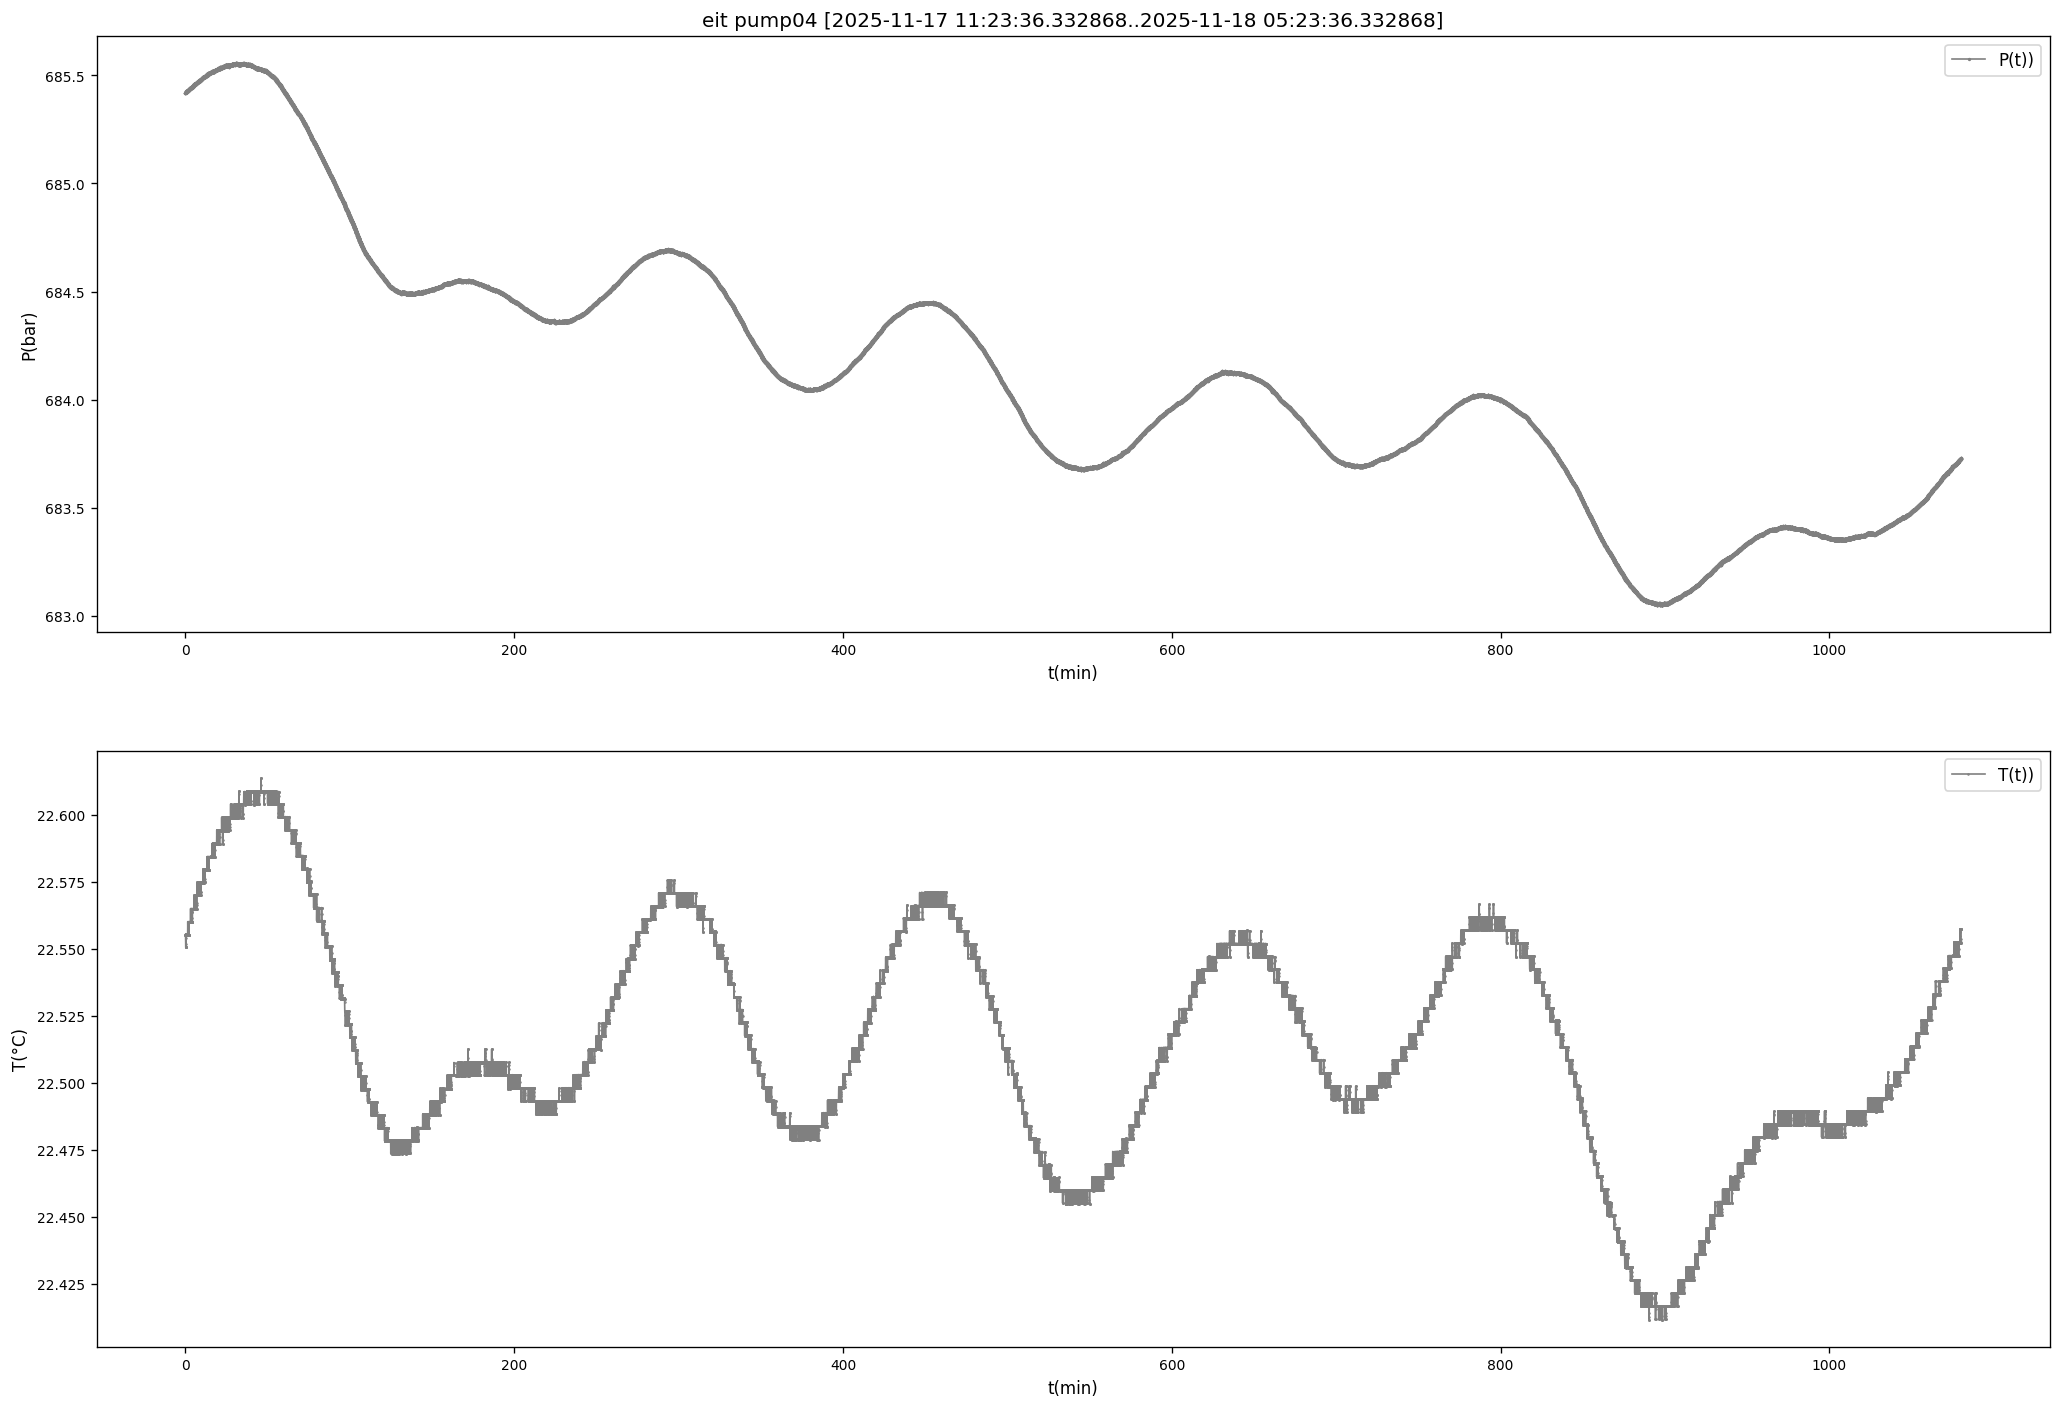

In [26]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# plot the data set P(t), T(t)

style = "seaborn-v0_8-dark-palette"
print(f"    using style {style}")
plt.style.use(style)

mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'

fig, ax = plt.subplots(2,1)
fig.set_size_inches(21,14)

dpi = 120
print(f"    using {dpi} dpi")
fig.set_dpi(dpi)

ax[0].plot(t, P,'.-', ms=2., lw=1., color='grey', label=f"P(t))")

ax[0].set_xlabel("t(min)")
ax[0].set_ylabel("P(bar)")
ax[0].legend()

ax[1].plot(t, T,'.-', ms=1., lw=1., color='grey', label=f"T(t))")

ax[1].set_xlabel("t(min)")
ax[1].set_ylabel("T(°C)")
ax[1].legend()

ax[0].set_title(f"{application} [{_start}..{_stop}]")
plt.subplots_adjust(bottom=0.1)


plot_file = os.path.join(data_folder, f"{prefix}_{filename}_ft.png")
if os.path.exists(plot_file):
    os.remove(plot_file)

print(f"    write {plot_file}")
plt.savefig(plot_file, dpi=dpi, facecolor='w')

plt.show()


    using style seaborn-v0_8-dark-palette
    using 120 dpi
    write C:\Develop\py\FluidicsLab\Drafts\report\data\12_eit pump04_report.pump04.png


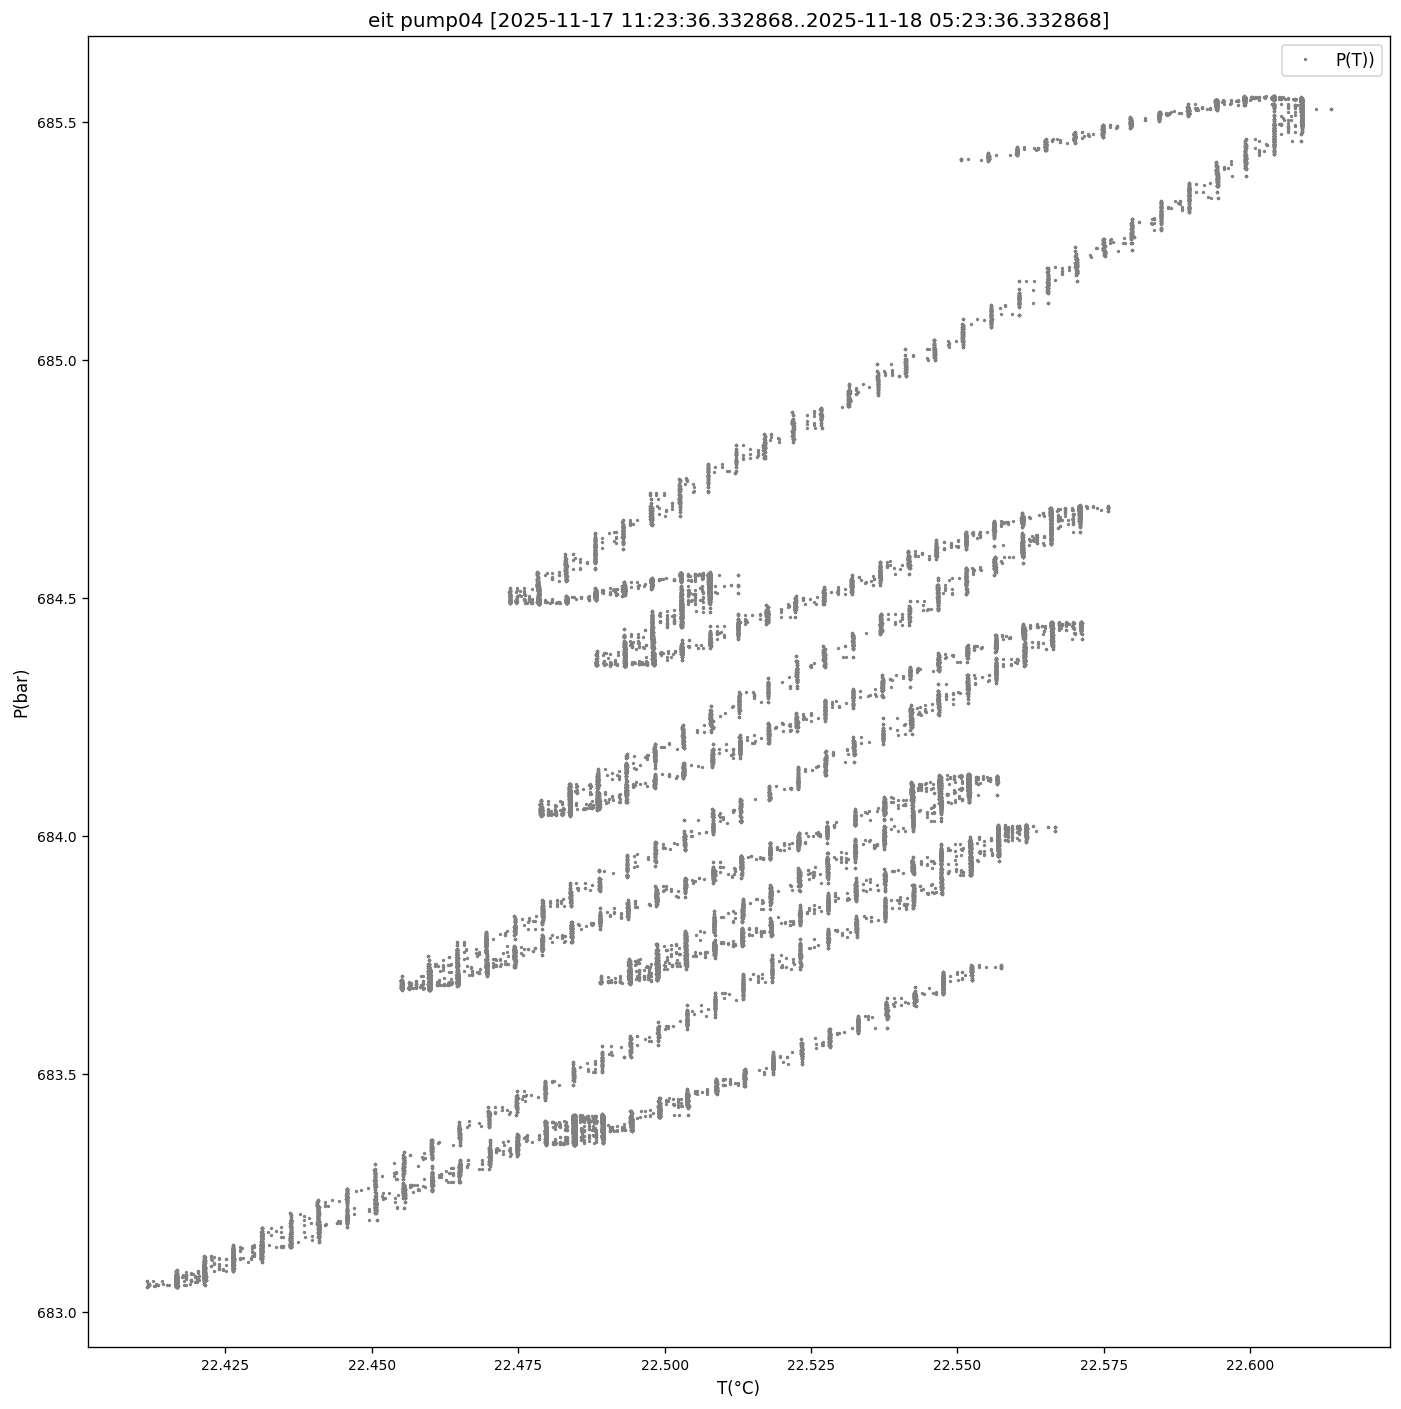

In [27]:

# plot the data set P(T)

style = "seaborn-v0_8-dark-palette"
print(f"    using style {style}")
plt.style.use(style)

mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'

fig, ax = plt.subplots(1,1)
fig.set_size_inches(14,14)

dpi = 120
print(f"    using {dpi} dpi")
fig.set_dpi(dpi)

ax.plot(T, P,'.', ms=2., lw=1., color='grey', label=f"P(T))")

ax.set_xlabel("T(°C)")
ax.set_ylabel("P(bar)")

ax.set_title(f"{application} [{_start}..{_stop}]")
plt.subplots_adjust(bottom=0.1)

plt.legend()

plot_file = os.path.join(data_folder, f"{prefix}_{filename}.png")
if os.path.exists(plot_file):
    os.remove(plot_file)

print(f"    write {plot_file}")
plt.savefig(plot_file, dpi=dpi, facecolor='w')

plt.show()